# GARCH Volatility Model for the S&P 500 or a Selected S&P 500 Constituent

**Project module:** GARCH volatility model  
**Default underlying:** S&P 500 Index (`^GSPC` from Yahoo Finance; fallback: FRED `SP500`)  
**Optional single-company mode:** change the ticker to any S&P 500 constituent such as `AAPL`, `MSFT`, `NVDA`, or `TSLA`  

## Project periods

| Period | Date range | Interpretation |
|---|---:|---|
| Stable | 2015-01-01 to 2018-12-31 | relatively calmer pre-COVID period |
| Unstable | 2019-01-01 to 2022-12-31 | includes COVID shock and 2022 inflation/rate-hike volatility |
| Total | 2015-01-01 to 2022-12-31 | full sample used for comparison |

## Goal of this notebook

Black--Scholes uses a constant volatility input. This notebook replaces that constant volatility with a **GARCH(1,1) time-varying volatility estimate** and evaluates whether this helps with:

1. volatility forecasting;
2. Black--Scholes option pricing with a dynamic volatility input;
3. synthetic European call delta hedging.

The main output of this module is a set of CSV files, LaTeX tables, and figures that can be uploaded to the team GitHub repository and compared with the Black--Scholes, HAR, path-dependent volatility, and machine-learning modules.

## How to switch from S&P 500 index to one S&P 500 company

In **Section 2: Configuration**, change the three lines below:

```python
UNDERLYING_MODE = "stock"
TICKER = "AAPL"
UNDERLYING_NAME = "Apple Inc."
```

Then click **Run All**. The same GARCH analysis will run for the selected ticker.

## 1. Setup

This notebook is designed to be easy to run in a clean environment.

- It uses `scipy.optimize` to estimate GARCH(1,1), so it does **not** require the external `arch` package.
- It uses `yfinance` to download market data. If `yfinance` is not installed, uncomment the installation line below.
- All output files are saved under the `output/` folder.

Expected output structure:

```text
output/
  figures/
  tables/
  garch_parameter_estimates.csv
  volatility_forecast_metrics.csv
  hedging_metrics.csv
  garch_hedging_details.csv
```

In [1]:
# Optional installation if running in a clean environment such as Google Colab:
# !pip install yfinance

# Core packages. We avoid the external `arch` package by implementing the
# GARCH(1,1) likelihood directly using scipy.optimize.

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm

warnings.filterwarnings("ignore")

OUTPUT_DIR = Path("output")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
for d in [OUTPUT_DIR, FIG_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Standard convention for annualizing daily volatility in U.S. equity markets.
TRADING_DAYS = 252

## 2. Configuration

The default setting uses the S&P 500 index. The same code can also be run for any individual S&P 500 company by changing `UNDERLYING_MODE`, `TICKER`, and `UNDERLYING_NAME`.

### Default index mode

```python
UNDERLYING_MODE = "index"
TICKER = "^GSPC"
UNDERLYING_NAME = "S&P 500 Index"
```

### Single-stock mode example

```python
UNDERLYING_MODE = "stock"
TICKER = "AAPL"
UNDERLYING_NAME = "Apple Inc."
```

### Notes for the team

- Keep the same date ranges across all models so that Black--Scholes, GARCH, HAR, path-dependent volatility, and ML results are comparable.
- For the main comparison, I recommend using the S&P 500 index or SPY as the broad-market case.
- For the optional single-company extension, choose one large S&P 500 constituent, such as Apple (`AAPL`) or Nvidia (`NVDA`).

In [2]:
# =========================
# User choices
# =========================

# Choose either "index" or "stock".
# - "index": default S&P 500 index analysis using ^GSPC.
# - "stock": one selected S&P 500 constituent, e.g. AAPL, MSFT, NVDA, TSLA.
UNDERLYING_MODE = "index"

# Default: S&P 500 index. For any S&P 500 company, replace these values.
# Examples:
#   TICKER = "AAPL"; UNDERLYING_NAME = "Apple Inc."
#   TICKER = "NVDA"; UNDERLYING_NAME = "NVIDIA Corporation"
TICKER = "^GSPC"
UNDERLYING_NAME = "S&P 500 Index"

# Optional validation. If True and UNDERLYING_MODE == "stock", the notebook tries
# to check whether TICKER is in the current S&P 500 list from Wikipedia.
# This requires internet access and can be left False for the main project.
VALIDATE_SP500_CONSTITUENT = False

# Full data window. These dates match the team-level stable/unstable/total design.
START_DATE = "2015-01-01"
END_DATE = "2022-12-31"

PERIODS = {
    "Stable":   ("2015-01-01", "2018-12-31"),
    "Unstable": ("2019-01-01", "2022-12-31"),
    "Total":    ("2015-01-01", "2022-12-31"),
}

# Volatility forecast evaluation: compare model volatility at date t with
# realized volatility over the next h trading days. 21 trading days is roughly
# one calendar month.
REALIZED_VOL_HORIZON = 21

# Synthetic European call option hedging setup.
# The team can later change this to 30/60/90 trading days if all modules agree.
OPTION_MATURITY_DAYS = 21

# Baseline annual risk-free rate used in Black--Scholes and cash-account growth.
# A later version can replace this constant with daily FRED 3-month Treasury rates.
RISK_FREE_RATE = 0.02

# Moneyness definitions for synthetic call options.
# ATM: K = S0; OTM: K = 1.05*S0; ITM: K = 0.95*S0.
MONEYNESS_LEVELS = {
    "ITM": 0.95,
    "ATM": 1.00,
    "OTM": 1.05,
}

# Safe version of ticker for filenames, since ^ and / are inconvenient in paths.
SAFE_TICKER = TICKER.replace("^", "").replace("/", "_")
print(f"Underlying mode: {UNDERLYING_MODE}")
print(f"Ticker: {TICKER}")
print(f"Underlying name: {UNDERLYING_NAME}")

Underlying mode: index
Ticker: ^GSPC
Underlying name: S&P 500 Index


## 3. Optional S&P 500 Constituent Validation

This step is optional. It is useful only if we switch to `UNDERLYING_MODE = "stock"` and want to verify that the selected ticker is currently an S&P 500 constituent.

For reproducibility, I leave this validation off by default because:

1. it requires internet access;
2. the current S&P 500 constituent list can change over time;
3. the main project does not require this validation when using the S&P 500 index.

In [3]:
def get_sp500_constituents_from_wikipedia():
    """Return a DataFrame of current S&P 500 constituents from Wikipedia.
    Yahoo Finance uses '-' instead of '.' for some tickers, e.g. BRK.B becomes BRK-B.
    """
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    tables = pd.read_html(url)
    constituents = tables[0].copy()
    constituents["YahooTicker"] = constituents["Symbol"].str.replace(".", "-", regex=False)
    return constituents

if VALIDATE_SP500_CONSTITUENT and UNDERLYING_MODE == "stock":
    try:
        sp500_constituents = get_sp500_constituents_from_wikipedia()
        if TICKER not in set(sp500_constituents["YahooTicker"]):
            print(f"Warning: {TICKER} was not found in the current S&P 500 constituent list.")
        else:
            row = sp500_constituents.loc[sp500_constituents["YahooTicker"] == TICKER].iloc[0]
            print(f"Validated: {TICKER} is in S&P 500. Company: {row.get('Security', '')}")
    except Exception as e:
        print(f"Could not validate S&P 500 membership: {e}")

## 4. Data Loading and Return Construction

### Required data for the GARCH module

The GARCH model only requires historical prices of the underlying asset. For this notebook, the required fields are:

- `date`
- `price`

For an index such as the S&P 500, `price` is the index close. For an individual stock, we prefer **adjusted close** because it accounts for splits and dividends. This avoids treating a stock split as a real market crash.

### Return definition

We compute daily log returns in percentage points:

$$
r_t = 100 \times \log\left(\frac{S_t}{S_{t-1}}\right).
$$

The factor 100 converts decimal returns into percent units. This improves numerical stability when estimating GARCH by maximum likelihood.

### Why not use option prices here?

The core GARCH model does **not** need historical option prices. It forecasts volatility from the underlying asset's return history. The predicted volatility can then be used as the volatility input in Black--Scholes pricing and delta hedging.

In [4]:
def load_from_yfinance(ticker=TICKER, start=START_DATE, end=END_DATE):
    """Download historical data from Yahoo Finance via yfinance."""
    import yfinance as yf
    df = yf.download(ticker, start=start, end=end, auto_adjust=False, progress=False)
    if df.empty:
        raise ValueError("yfinance returned an empty DataFrame.")
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [c[0] for c in df.columns]
    # For stocks, prefer adjusted close. For index tickers, Adj Close may equal Close or be absent.
    price_col = "Adj Close" if "Adj Close" in df.columns else "Close"
    out = df[[price_col]].rename(columns={price_col: "price"})
    out.index = pd.to_datetime(out.index)
    out = out.sort_index()
    return out


def load_sp500_from_fred(start=START_DATE, end=END_DATE):
    """Fallback download from FRED SP500 series. It may not include the full 2015 sample due to FRED's rolling 10-year limit."""
    url = (
        "https://fred.stlouisfed.org/graph/fredgraph.csv"
        f"?id=SP500&observation_start={start}&observation_end={end}"
    )
    df = pd.read_csv(url)
    df.columns = ["date", "price"]
    df["date"] = pd.to_datetime(df["date"])
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df = df.dropna().set_index("date").sort_index()
    return df


def load_local_price_data(ticker=TICKER):
    """Load a local CSV if available. Accepted columns: date plus adj_close/adjusted_close/close/price/value."""
    safe = ticker.replace("^", "").replace(".", "-").replace("/", "-")
    local_candidates = [
        Path(f"data/{safe}.csv"),
        Path(f"data/{ticker}.csv"),
        Path(f"{safe}.csv"),
        Path(f"{ticker}.csv"),
        Path("data/sp500.csv"),
        Path("sp500.csv"),
        Path("SP500.csv"),
    ]
    for p in local_candidates:
        if p.exists():
            df = pd.read_csv(p)
            date_candidates = [c for c in df.columns if c.lower() in ["date", "datetime"]]
            if not date_candidates:
                raise ValueError(f"Cannot find date column in {p}.")
            date_col = date_candidates[0]
            price_candidates = [
                c for c in df.columns
                if c.lower().replace(" ", "_") in ["adj_close", "adjusted_close", "close", "price", "value"]
            ]
            if not price_candidates:
                raise ValueError(f"Cannot find price column in {p}.")
            # Prefer adjusted close when available.
            price_col = None
            for preferred in ["adj_close", "adjusted_close", "price", "close", "value"]:
                for c in price_candidates:
                    if c.lower().replace(" ", "_") == preferred:
                        price_col = c
                        break
                if price_col is not None:
                    break
            df[date_col] = pd.to_datetime(df[date_col])
            out = df[[date_col, price_col]].rename(columns={date_col: "date", price_col: "price"})
            out["price"] = pd.to_numeric(out["price"], errors="coerce")
            out = out.dropna().set_index("date").sort_index()
            print(f"Loaded local data from {p}")
            return out
    return None


def load_price_data(ticker=TICKER):
    """Load selected underlying data. Prefer local CSV, then yfinance, then FRED fallback for S&P 500 index only."""
    local = load_local_price_data(ticker)
    if local is not None:
        return local

    try:
        df = load_from_yfinance(ticker)
        print(f"Loaded {ticker} data from yfinance.")
        return df
    except Exception as e:
        print(f"yfinance failed for {ticker}: {e}")
        if ticker in ["^GSPC", "SP500"] or UNDERLYING_MODE == "index":
            print("Trying FRED S&P 500 fallback...")
            df = load_sp500_from_fred()
            print("Loaded S&P 500 data from FRED.")
            return df
        raise

prices = load_price_data(TICKER)
prices = prices.loc[START_DATE:END_DATE].copy()
prices["log_return"] = 100 * np.log(prices["price"] / prices["price"].shift(1))
prices = prices.dropna()

print(prices.head())
print(prices.tail())
print(f"Number of return observations: {len(prices)}")

prices.to_csv(OUTPUT_DIR / f"{SAFE_TICKER}_prices_returns.csv")

yfinance failed for ^GSPC: No module named 'yfinance'
Trying FRED S&P 500 fallback...
Loaded S&P 500 data from FRED.
              price  log_return
date                           
2016-06-21  2088.90    0.270844
2016-06-22  2085.45   -0.165295
2016-06-23  2113.32    1.327551
2016-06-24  2037.41   -3.658078
2016-06-27  2000.54   -1.826225
              price  log_return
date                           
2022-12-23  3844.82    0.585091
2022-12-27  3829.25   -0.405783
2022-12-28  3783.22   -1.209346
2022-12-29  3849.28    1.731062
2022-12-30  3839.50   -0.254397
Number of return observations: 1645


### Quick data diagnostics

The two plots below check whether the downloaded price and return series look reasonable.

- The price plot should not contain artificial jumps from splits or data errors.
- The return plot should show volatility clustering: calm periods and turbulent periods.
- If the selected stock has missing prices or extreme outliers, the data should be cleaned before comparing models.

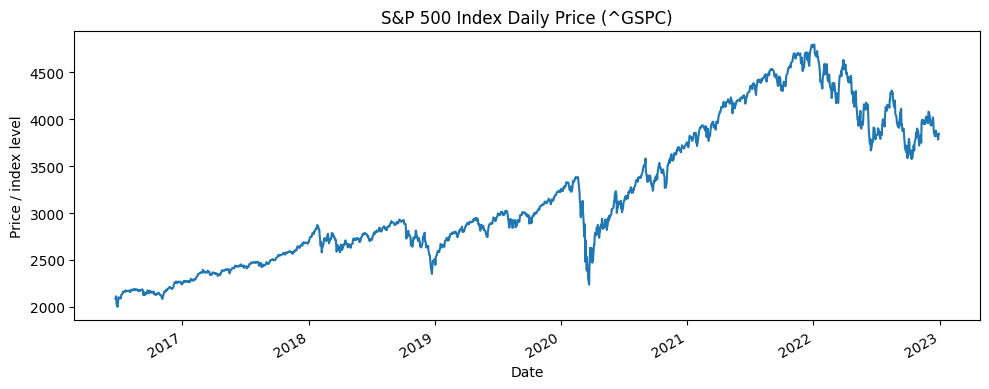

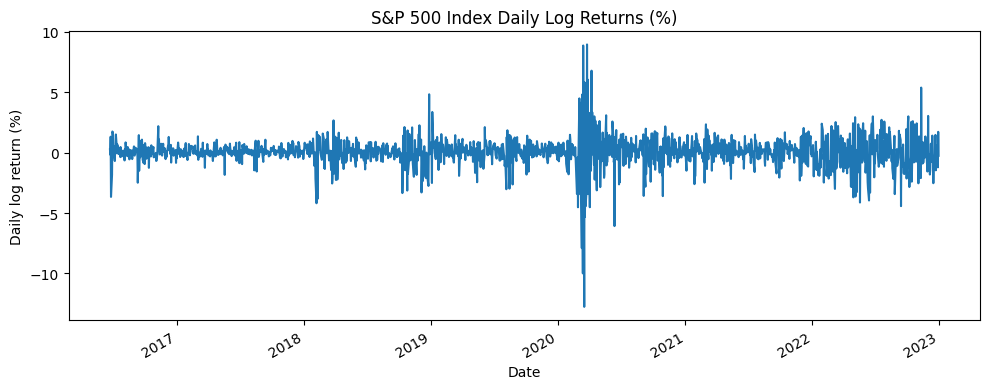

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
prices["price"].plot(ax=ax)
ax.set_title(f"{UNDERLYING_NAME} Daily Price ({TICKER})")
ax.set_ylabel("Price / index level")
ax.set_xlabel("Date")
plt.tight_layout()
plt.savefig(FIG_DIR / f"{SAFE_TICKER}_price.png", dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
prices["log_return"].plot(ax=ax)
ax.set_title(f"{UNDERLYING_NAME} Daily Log Returns (%)")
ax.set_ylabel("Daily log return (%)")
ax.set_xlabel("Date")
plt.tight_layout()
plt.savefig(FIG_DIR / f"{SAFE_TICKER}_returns.png", dpi=200)
plt.show()

## 5. GARCH(1,1) Model

### Why GARCH?

Black--Scholes assumes a constant volatility input. In real financial markets, volatility is usually time-varying and clustered: large movements tend to be followed by more large movements, and calm periods tend to remain calm. GARCH is a standard econometric model designed to capture this pattern.

### Model equations

The return equation is:

$$
r_t = \mu + \epsilon_t.
$$

The shock decomposition is:

$$
\epsilon_t = \sigma_t z_t, \quad z_t \sim N(0,1).
$$

The GARCH(1,1) conditional variance equation is:

$$
\sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2.
$$

### Parameter interpretation

- $\omega$: baseline variance level;
- $\alpha$: sensitivity to recent return shocks;
- $\beta$: persistence of volatility;
- $\alpha + \beta$: overall persistence of volatility.

Important implementation note: we choose the model structure, such as GARCH(1,1), but we do **not** manually choose $\alpha$ or $\beta$. The parameters $\omega$, $\alpha$, and $\beta$ are estimated from historical returns.

In [6]:
def garch11_filter(returns, omega, alpha, beta, mu=None):
    """Compute conditional variances for GARCH(1,1).

    Parameters
    ----------
    returns : array-like
        Daily log returns in percent units, e.g. 1.0 means 1%.
    omega, alpha, beta : float
        GARCH(1,1) parameters. These are estimated by maximum likelihood.
    mu : float or None
        Mean return. If None, use sample mean.

    Returns
    -------
    eps : ndarray
        Return shocks r_t - mu.
    sigma2 : ndarray
        Conditional variances in squared percent-return units.
    """
    r = np.asarray(returns, dtype=float)
    if mu is None:
        mu = np.mean(r)
    eps = r - mu
    n = len(eps)
    sigma2 = np.empty(n)
    unconditional_var = omega / max(1e-8, (1 - alpha - beta)) if alpha + beta < 0.999 else np.var(eps)
    sigma2[0] = max(np.var(eps), unconditional_var, 1e-8)
    for t in range(1, n):
        sigma2[t] = omega + alpha * eps[t-1]**2 + beta * sigma2[t-1]
        if sigma2[t] <= 1e-12 or not np.isfinite(sigma2[t]):
            sigma2[t] = 1e-12
    return eps, sigma2


def garch11_negloglik(params, returns):
    """Gaussian negative log likelihood for GARCH(1,1), with stationarity constraints."""
    omega, alpha, beta = params
    if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 0.999:
        return 1e12
    mu = np.mean(returns)
    eps, sigma2 = garch11_filter(returns, omega, alpha, beta, mu=mu)
    ll = -0.5 * (np.log(2 * np.pi) + np.log(sigma2) + eps**2 / sigma2)
    if not np.all(np.isfinite(ll)):
        return 1e12
    return -np.sum(ll)


def fit_garch11(returns):
    """Fit GARCH(1,1) using scipy.optimize. Returns are in percent units."""
    r = pd.Series(returns).dropna().astype(float)
    var = np.var(r)
    x0 = np.array([0.05 * var, 0.05, 0.90])
    bounds = [(1e-10, 10 * var + 1e-6), (1e-8, 0.999), (1e-8, 0.999)]
    cons = ({"type": "ineq", "fun": lambda x: 0.999 - x[1] - x[2]})
    res = minimize(
        garch11_negloglik,
        x0=x0,
        args=(r.values,),
        method="SLSQP",
        bounds=bounds,
        constraints=cons,
        options={"maxiter": 2000, "ftol": 1e-9, "disp": False},
    )
    if not res.success:
        print("Warning: optimizer did not fully converge:", res.message)
    omega, alpha, beta = res.x
    mu = r.mean()
    eps, sigma2 = garch11_filter(r.values, omega, alpha, beta, mu=mu)
    out = {
        "mu": mu,
        "omega": omega,
        "alpha": alpha,
        "beta": beta,
        "alpha_plus_beta": alpha + beta,
        "loglik": -res.fun,
        "success": res.success,
        "message": res.message,
        "conditional_vol_daily_pct": pd.Series(np.sqrt(sigma2), index=r.index),
        "eps": pd.Series(eps, index=r.index),
    }
    return out


def annualize_vol_from_pct(daily_vol_pct):
    """Convert daily volatility in percent units to annual decimal volatility."""
    return daily_vol_pct / 100 * np.sqrt(TRADING_DAYS)

## 6. Volatility Forecast Accuracy

This section evaluates how well each volatility estimate predicts future realized volatility.

For each date $t$, we compare model-implied volatility $\hat{\sigma}_t$ to realized volatility over the next $h$ trading days:

$$
RV_{t,t+h} = \sqrt{252}\, \operatorname{sd}\left(r_{t+1},\ldots,r_{t+h}\right),
$$

where returns are converted from percent units back to decimal units before annualization.

### Metrics

Let

$$
e_t = \hat{\sigma}_t - RV_{t,t+h}.
$$

Then:

$$
MSE = \frac{1}{n}\sum_{t=1}^n e_t^2,
$$

$$
RMSE = \sqrt{MSE},
$$

$$
MAE = \frac{1}{n}\sum_{t=1}^n |e_t|.
$$

Interpretation:

- **MAE** measures the average absolute forecast error.
- **RMSE** penalizes large forecast errors more heavily.
- **Mean Error** shows whether the model systematically overpredicts or underpredicts volatility.

In [7]:
def future_realized_vol_ann(returns_pct, horizon=REALIZED_VOL_HORIZON):
    """Future realized annualized volatility from t+1 to t+h, aligned at t."""
    rv_pct_daily = returns_pct.rolling(horizon).std().shift(-horizon)
    return rv_pct_daily / 100 * np.sqrt(TRADING_DAYS)


def compute_error_metrics(pred, target):
    df = pd.concat([pd.Series(pred, name="pred"), pd.Series(target, name="target")], axis=1).dropna()
    if df.empty:
        return {"N": 0, "MSE": np.nan, "RMSE": np.nan, "MAE": np.nan, "Mean_Error": np.nan}
    err = df["pred"] - df["target"]
    return {
        "N": len(df),
        "MSE": float(np.mean(err**2)),
        "RMSE": float(np.sqrt(np.mean(err**2))),
        "MAE": float(np.mean(np.abs(err))),
        "Mean_Error": float(np.mean(err)),
    }


def period_slice(df, start, end):
    return df.loc[pd.to_datetime(start):pd.to_datetime(end)].copy()

vol_series_by_period = {}
param_rows = []
forecast_rows = []

for label, (start, end) in PERIODS.items():
    d = period_slice(prices, start, end)
    r = d["log_return"].dropna()
    if len(r) < 100:
        print(f"Skipping {label}: too few observations ({len(r)}).")
        continue

    const_vol_ann = pd.Series(r.std() / 100 * np.sqrt(TRADING_DAYS), index=r.index)
    rolling_vol_ann = r.rolling(21).std() / 100 * np.sqrt(TRADING_DAYS)

    fit = fit_garch11(r)
    garch_vol_ann = annualize_vol_from_pct(fit["conditional_vol_daily_pct"])
    rv = future_realized_vol_ann(r, horizon=REALIZED_VOL_HORIZON)

    vol_series_by_period[label] = pd.DataFrame({
        "price": d.loc[r.index, "price"],
        "return_pct": r,
        "constant_vol_ann": const_vol_ann,
        "rolling21_vol_ann": rolling_vol_ann,
        "garch_vol_ann": garch_vol_ann,
        "future_realized_vol_ann": rv,
    })

    param_rows.append({
        "Underlying": UNDERLYING_NAME,
        "Ticker": TICKER,
        "Period": label,
        "Start": start,
        "End": end,
        "N": len(r),
        "mu": fit["mu"],
        "omega": fit["omega"],
        "alpha": fit["alpha"],
        "beta": fit["beta"],
        "alpha_plus_beta": fit["alpha_plus_beta"],
        "loglik": fit["loglik"],
    })

    for model_name, pred in {
        "Constant": const_vol_ann,
        "Rolling21": rolling_vol_ann,
        "GARCH(1,1)": garch_vol_ann,
    }.items():
        m = compute_error_metrics(pred, rv)
        forecast_rows.append({"Underlying": UNDERLYING_NAME, "Ticker": TICKER, "Period": label, "Model": model_name, **m})

params_df = pd.DataFrame(param_rows)
forecast_metrics_df = pd.DataFrame(forecast_rows)

print("GARCH parameter estimates:")
display(params_df)

print("Volatility forecast metrics:")
display(forecast_metrics_df)

params_df.to_csv(OUTPUT_DIR / f"{SAFE_TICKER}_garch_parameter_estimates.csv", index=False)
forecast_metrics_df.to_csv(OUTPUT_DIR / f"{SAFE_TICKER}_volatility_forecast_metrics.csv", index=False)
params_df.to_latex(TABLE_DIR / "garch_parameter_estimates.tex", index=False, float_format="%.4f")
forecast_metrics_df.to_latex(TABLE_DIR / "volatility_forecast_metrics.tex", index=False, float_format="%.4f")

GARCH parameter estimates:


,Underlying,Ticker,Period,Start,End,N,mu,omega,alpha,beta,alpha_plus_beta,loglik
0,S&P 500 Index,^GSPC,Stable,2015-01-01,2018-12-31,637,0.029058,0.032981,0.235543,0.752736,0.988279,-636.686158
1,S&P 500 Index,^GSPC,Unstable,2019-01-01,2022-12-31,1008,0.042293,0.047892,0.213400,0.771930,0.985331,-1505.322051
2,S&P 500 Index,^GSPC,Total,2015-01-01,2022-12-31,1645,0.037168,0.034613,0.217131,0.772490,0.989621,-2144.398601


Volatility forecast metrics:


,Underlying,Ticker,Period,Model,N,MSE,RMSE,MAE,Mean_Error
0,S&P 500 Index,^GSPC,Stable,Constant,616,0.004099,0.064021,0.057750,0.023481
1,S&P 500 Index,^GSPC,Stable,Rolling21,596,0.003403,0.058333,0.037846,-0.004776
2,S&P 500 Index,^GSPC,Stable,"GARCH(1,1)",616,0.004002,0.063263,0.045336,0.011963
3,S&P 500 Index,^GSPC,Unstable,Constant,987,0.020283,0.142420,0.099960,0.042660
4,S&P 500 Index,^GSPC,Unstable,Rolling21,967,0.020068,0.141661,0.080232,-0.002173
5,S&P 500 Index,^GSPC,Unstable,"GARCH(1,1)",987,0.016198,0.127272,0.074709,0.006809
6,S&P 500 Index,^GSPC,Total,Constant,1624,0.016021,0.126576,0.092270,0.040064
7,S&P 500 Index,^GSPC,Total,Rolling21,1604,0.013777,0.117375,0.065424,-0.001612
8,S&P 500 Index,^GSPC,Total,"GARCH(1,1)",1624,0.011728,0.108294,0.064485,0.007897


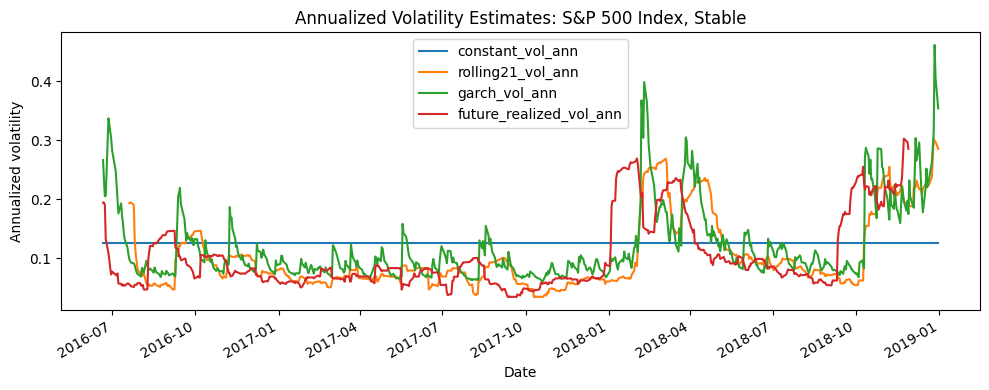

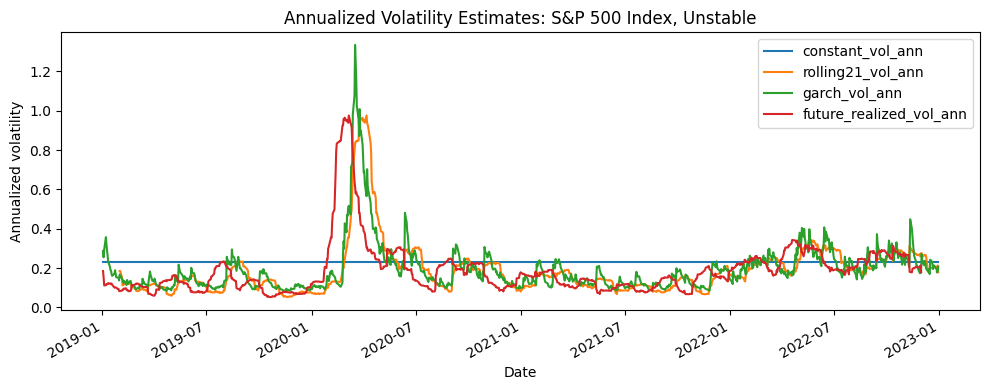

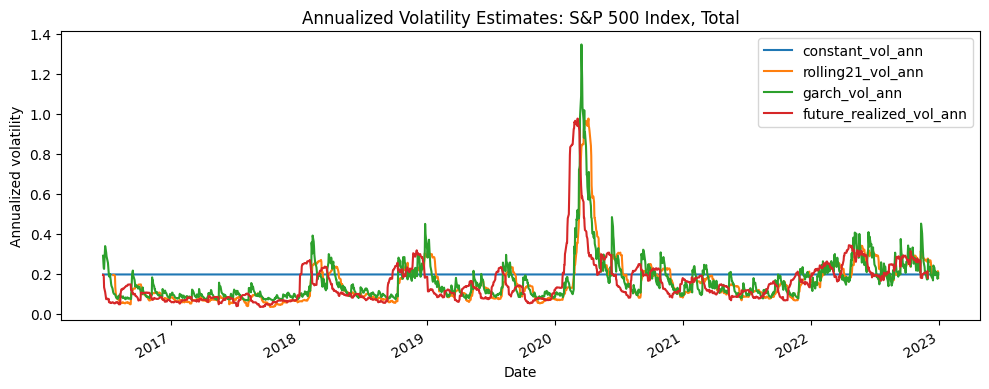

In [8]:
for label, dfv in vol_series_by_period.items():
    fig, ax = plt.subplots(figsize=(10, 4))
    dfv[["constant_vol_ann", "rolling21_vol_ann", "garch_vol_ann", "future_realized_vol_ann"]].plot(ax=ax)
    ax.set_title(f"Annualized Volatility Estimates: {UNDERLYING_NAME}, {label}")
    ax.set_ylabel("Annualized volatility")
    ax.set_xlabel("Date")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{SAFE_TICKER}_volatility_{label.lower()}.png", dpi=200)
    plt.show()

## 7. Black--Scholes Pricing and Delta

The GARCH model produces a time-varying volatility estimate. To connect it to option pricing, we plug that volatility into the standard Black--Scholes formula.

For a European call option:

$$
C = S\Phi(d_1) - K e^{-rT}\Phi(d_2),
$$

where

$$
d_1 = \frac{\log(S/K) + \left(r + \sigma^2/2\right)T}{\sigma\sqrt{T}},
\qquad
d_2 = d_1 - \sigma\sqrt{T}.
$$

The call delta is:

$$
\Delta = \Phi(d_1).
$$

All models use the same Black--Scholes formula. The only thing that changes is the volatility input $\sigma$:

- constant historical volatility;
- rolling realized volatility;
- GARCH time-varying volatility.

In [9]:
def bs_call_price(S, K, T, r, sigma):
    if T <= 0:
        return max(S - K, 0.0)
    sigma = max(float(sigma), 1e-8)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def bs_call_delta(S, K, T, r, sigma):
    if T <= 0:
        return 1.0 if S > K else 0.0
    sigma = max(float(sigma), 1e-8)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

## 8. Synthetic Delta-Hedging Backtest

We use synthetic European call options so that the GARCH module does not depend on difficult-to-clean historical option quote data.

### Option construction

For each option start date:

1. observe the initial underlying price $S_0$;
2. set strike $K = mS_0$, where $m$ is the moneyness multiplier;
3. price the call using Black--Scholes with the model-specific volatility;
4. compute the model-specific delta;
5. rebalance the hedge daily until maturity.

### Hedging error

At expiration, the call payoff is:

$$
\max(S_T-K,0).
$$

The hedging error is:

$$
HE = V_T - \max(S_T-K,0),
$$

where $V_T$ is the final value of the hedging portfolio.

A smaller absolute hedging error means the model produced a more effective delta hedge.

In [10]:
def run_delta_hedge(price_series, vol_series, maturity_days=OPTION_MATURITY_DAYS, moneyness=1.0, r=RISK_FREE_RATE):
    """Run a synthetic short-call delta-hedging backtest.

    The strategy starts one synthetic call option every `maturity_days` trading days.
    At initiation, the strategy shorts one call, buys Delta shares of the underlying,
    and keeps the remaining value in a cash account. Each trading day, Delta is
    recomputed using the model-specific volatility and the stock position is
    rebalanced.

    Returns a DataFrame with one row per synthetic option contract.
    """
    df = pd.concat([price_series.rename("S"), vol_series.rename("sigma")], axis=1).dropna()
    df = df[df["sigma"] > 0].copy()
    if len(df) <= maturity_days + 5:
        return pd.DataFrame()

    start_locs = list(range(0, len(df) - maturity_days, maturity_days))
    rows = []
    r_daily = r / TRADING_DAYS

    for loc in start_locs:
        window = df.iloc[loc:loc + maturity_days + 1].copy()
        if len(window) < maturity_days + 1:
            continue
        S0 = float(window["S"].iloc[0])
        K = moneyness * S0
        sigma0 = float(window["sigma"].iloc[0])
        T0 = maturity_days / TRADING_DAYS
        option_price0 = bs_call_price(S0, K, T0, r, sigma0)
        delta = bs_call_delta(S0, K, T0, r, sigma0)

        # Short one call, buy delta shares, residual in cash.
        cash = option_price0 - delta * S0

        # Daily rebalancing.
        for j in range(1, len(window)):
            S_t = float(window["S"].iloc[j])
            sigma_t = float(window["sigma"].iloc[j])
            tau = max((maturity_days - j) / TRADING_DAYS, 0.0)
            cash *= (1 + r_daily)
            new_delta = bs_call_delta(S_t, K, tau, r, sigma_t)
            cash -= (new_delta - delta) * S_t
            delta = new_delta

        ST = float(window["S"].iloc[-1])
        payoff = max(ST - K, 0.0)
        portfolio_value = cash + delta * ST
        hedging_error = portfolio_value - payoff
        rows.append({
            "start_date": window.index[0],
            "end_date": window.index[-1],
            "S0": S0,
            "ST": ST,
            "K": K,
            "moneyness_multiplier": moneyness,
            "initial_sigma": sigma0,
            "initial_option_price": option_price0,
            "final_payoff": payoff,
            "portfolio_value": portfolio_value,
            "hedging_error": hedging_error,
        })
    return pd.DataFrame(rows)


def hedging_metric_table(df):
    if df.empty:
        return {"N": 0, "Mean_HE": np.nan, "MAE_HE": np.nan, "RMSE_HE": np.nan, "Worst_Loss": np.nan}
    he = df["hedging_error"]
    return {
        "N": len(he),
        "Mean_HE": float(he.mean()),
        "MAE_HE": float(np.mean(np.abs(he))),
        "RMSE_HE": float(np.sqrt(np.mean(he**2))),
        "Worst_Loss": float(he.min()),
    }

hedge_rows = []
all_hedges = []

for label, dfv in vol_series_by_period.items():
    for model_name, vol_col in {
        "Constant": "constant_vol_ann",
        "Rolling21": "rolling21_vol_ann",
        "GARCH(1,1)": "garch_vol_ann",
    }.items():
        for mon_label, mon_mult in MONEYNESS_LEVELS.items():
            h = run_delta_hedge(
                price_series=dfv["price"],
                vol_series=dfv[vol_col],
                maturity_days=OPTION_MATURITY_DAYS,
                moneyness=mon_mult,
                r=RISK_FREE_RATE,
            )
            if not h.empty:
                h["Underlying"] = UNDERLYING_NAME
                h["Ticker"] = TICKER
                h["Period"] = label
                h["Model"] = model_name
                h["Moneyness"] = mon_label
                all_hedges.append(h)
            m = hedging_metric_table(h)
            hedge_rows.append({"Underlying": UNDERLYING_NAME, "Ticker": TICKER, "Period": label, "Model": model_name, "Moneyness": mon_label, **m})

hedging_metrics_df = pd.DataFrame(hedge_rows)
hedging_details_df = pd.concat(all_hedges, ignore_index=True) if all_hedges else pd.DataFrame()

print("Delta-hedging metrics:")
display(hedging_metrics_df)

hedging_metrics_df.to_csv(OUTPUT_DIR / f"{SAFE_TICKER}_hedging_metrics.csv", index=False)
hedging_details_df.to_csv(OUTPUT_DIR / f"{SAFE_TICKER}_hedging_details.csv", index=False)
hedging_metrics_df.to_latex(TABLE_DIR / "hedging_metrics.tex", index=False, float_format="%.4f")

Delta-hedging metrics:


,Underlying,Ticker,Period,Model,Moneyness,N,Mean_HE,MAE_HE,RMSE_HE,Worst_Loss
0,S&P 500 Index,^GSPC,Stable,Constant,ITM,30,-4.507527,6.310038,13.923774,-58.200569
1,S&P 500 Index,^GSPC,Stable,Constant,ATM,30,3.668118,16.027466,18.647988,-36.499003
2,S&P 500 Index,^GSPC,Stable,Constant,OTM,30,3.070562,5.641095,7.077674,-20.348146
3,S&P 500 Index,^GSPC,Stable,Rolling21,ITM,29,-3.051022,6.466871,14.446371,-55.505051
4,S&P 500 Index,^GSPC,Stable,Rolling21,ATM,29,0.536839,12.150952,18.469881,-47.443655
5,S&P 500 Index,^GSPC,Stable,Rolling21,OTM,29,1.832756,3.618320,7.694397,-10.551833
6,S&P 500 Index,^GSPC,Stable,"GARCH(1,1)",ITM,30,-2.782838,4.778981,10.329836,-37.804810
7,S&P 500 Index,^GSPC,Stable,"GARCH(1,1)",ATM,30,2.154909,10.468324,13.408142,-33.987648
8,S&P 500 Index,^GSPC,Stable,"GARCH(1,1)",OTM,30,2.430626,4.828453,9.020603,-20.832567
9,S&P 500 Index,^GSPC,Unstable,Constant,ITM,47,0.896355,20.439833,30.768117,-118.008140


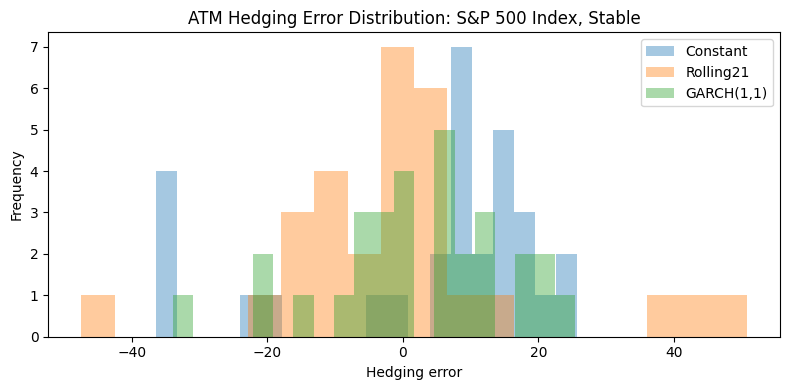

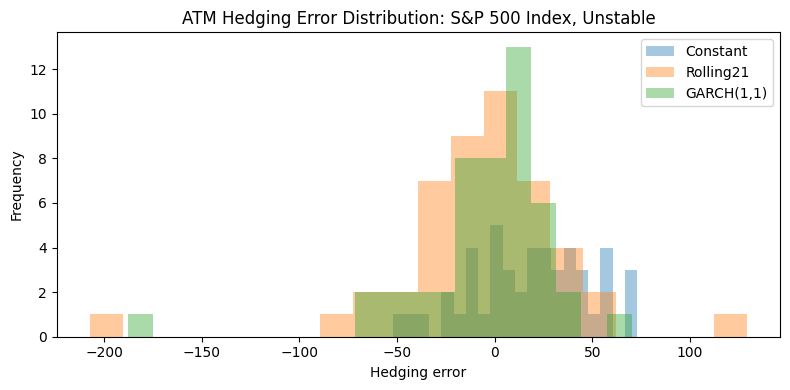

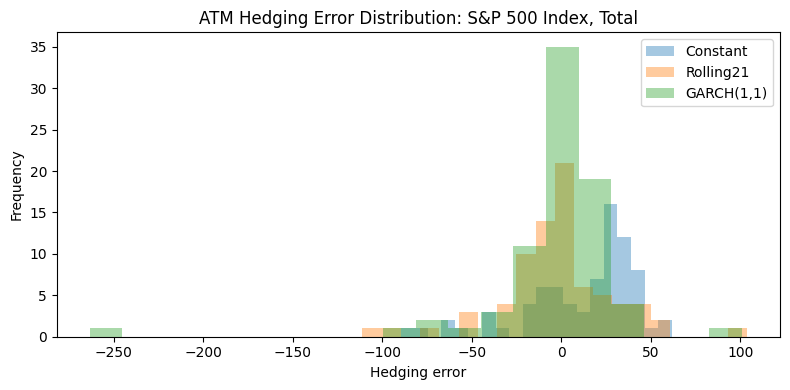

In [11]:
if not hedging_details_df.empty:
    for label in hedging_details_df["Period"].unique():
        tmp = hedging_details_df[hedging_details_df["Period"] == label]
        fig, ax = plt.subplots(figsize=(8, 4))
        for model_name in tmp["Model"].unique():
            tmp_m = tmp[(tmp["Model"] == model_name) & (tmp["Moneyness"] == "ATM")]
            if not tmp_m.empty:
                tmp_m["hedging_error"].plot(kind="hist", bins=20, alpha=0.4, ax=ax, label=model_name)
        ax.set_title(f"ATM Hedging Error Distribution: {UNDERLYING_NAME}, {label}")
        ax.set_xlabel("Hedging error")
        ax.legend()
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"{SAFE_TICKER}_hedging_error_hist_{label.lower()}.png", dpi=200)
        plt.show()